In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from PIL import Image

    Required libraries were imported for image processing and CNN model building.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving labels.csv to labels.csv


''

In [4]:
import pandas as pd
df = pd.read_csv('labels.csv')

In [5]:
df.columns

Index(['filename', 'class'], dtype='object')

In [8]:
from google.colab import files

uploaded = files.upload()

Saving images.zip to images.zip


In [9]:
import zipfile


with zipfile.ZipFile('images.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [10]:
import os
os.listdir('images')

['.DS_Store', 'normal', 'stain', 'dent', 'scratch']

In [11]:
os.listdir('images/normal')[:5]

['normal_093.png',
 'normal_038.png',
 'normal_036.png',
 'normal_059.png',
 'normal_089.png']

In [12]:
import os
print(os.path.exists(df['filename'][0]))

True


   The dataset consists of labeled images across four categories: normal, scratch, dent, and stain.

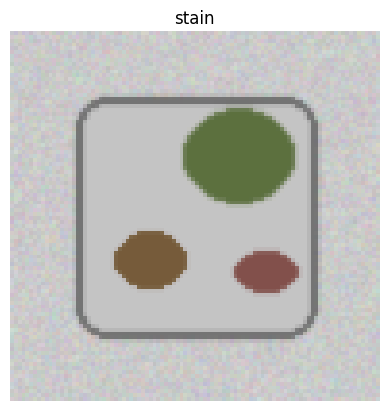

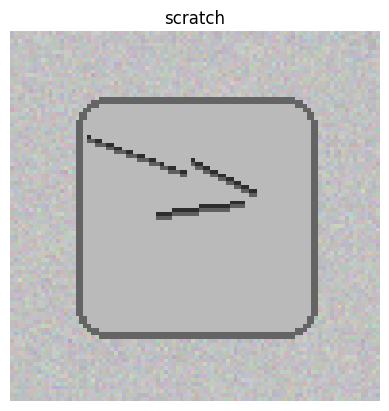

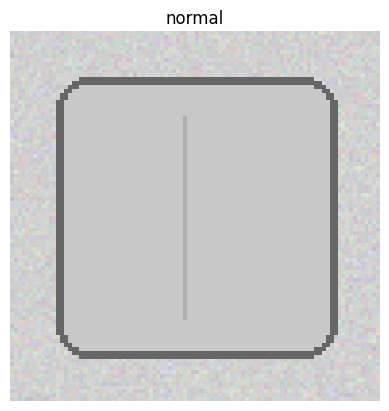

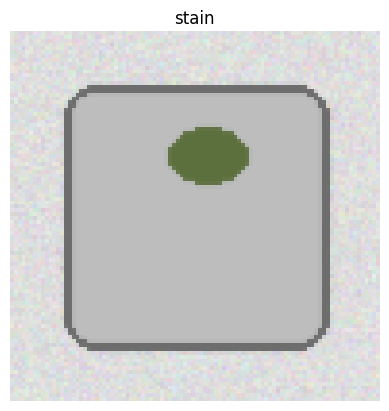

In [16]:
sample = df.sample(4)

for path in sample['filename']:
    img = Image.open(path)
    plt.imshow(img)
    plt.title(path.split('/')[-2])
    plt.axis('off')
    plt.show()

  Sample images were visualized to understand differences between classes.

This is an image classification problem where each image belongs to one class among normal, dent, scratch, and stain.

In [19]:
IMG_SIZE = 128

images = []
labels = []

for index, row in df.iterrows():
    try:
        img = Image.open(row['filename']).resize((IMG_SIZE, IMG_SIZE))
        img = np.array(img)
        images.append(img)
        labels.append(row['class'])
    except:
        continue

X = np.array(images)
y = np.array(labels)

print("Shape:", X.shape)

Shape: (480, 128, 128, 3)


In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

X = X / 255.0

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Images were resized, normalized, and split into training and test datasets.

In [25]:
model = tf.keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(4, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

A CNN model was built using convolution, pooling, and dense layers for image classification.

In [29]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.2500 - loss: 2.2105 - val_accuracy: 0.1875 - val_loss: 1.4157
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 807ms/step - accuracy: 0.2839 - loss: 1.3801 - val_accuracy: 0.5104 - val_loss: 1.3578
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 937ms/step - accuracy: 0.4531 - loss: 1.3367 - val_accuracy: 0.7812 - val_loss: 1.2669
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 982ms/step - accuracy: 0.5208 - loss: 1.1674 - val_accuracy: 0.5833 - val_loss: 1.1065
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 960ms/step - accuracy: 0.6380 - loss: 0.9309 - val_accuracy: 0.6667 - val_loss: 0.8953
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 970ms/step - accuracy: 0.7005 - loss: 0.6985 - val_accuracy: 0.7500 - val_loss: 0.6584
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 910ms/step - accuracy: 0.7812 - loss: 0.5573 - val_accuracy: 0.8750 - val_loss: 0.5717
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 816ms/step - accuracy: 0.8932 - loss: 0.3840 - val_accurac

The model was trained on the training data and validated using test data.

In [31]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step - accuracy: 0.8750 - loss: 0.3519
Test Accuracy: 0.875


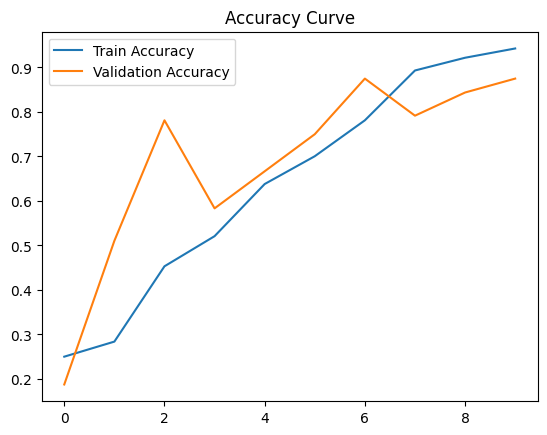

In [33]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 246ms/step


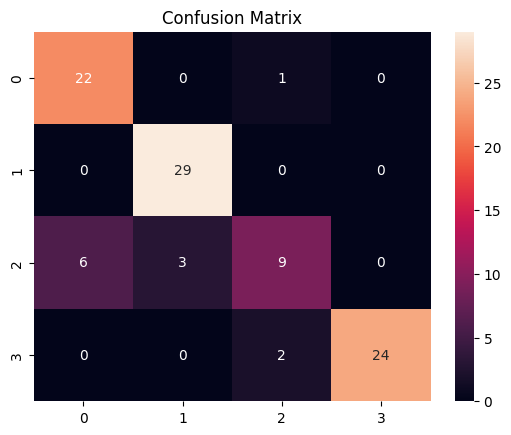

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

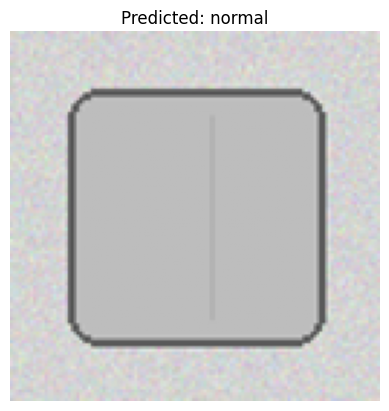

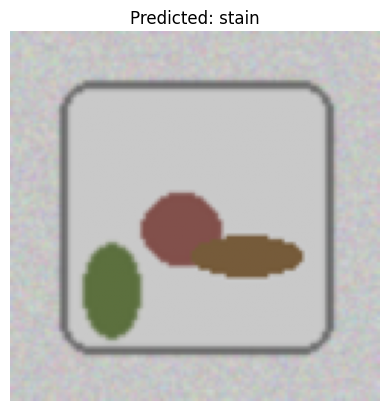

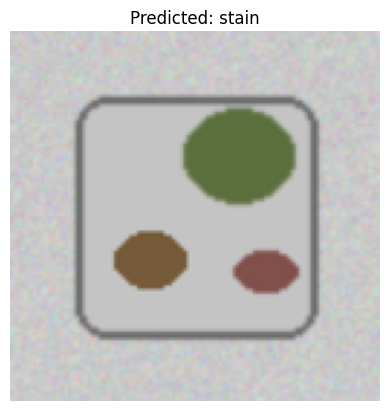

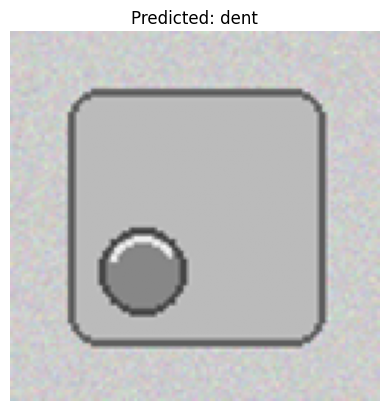

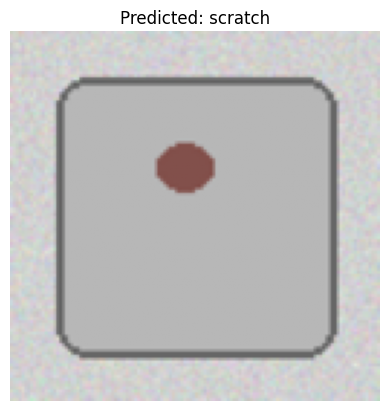

In [37]:
for i in range(5):
    plt.imshow(X_test[i])
    pred = le.inverse_transform([y_pred[i]])
    plt.title("Predicted: " + pred[0])
    plt.axis('off')
    plt.show()

In [39]:
history_exp = model.fit(
    X_train, y_train,
    epochs=15,
    validation_data=(X_test, y_test)
)

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 854ms/step - accuracy: 0.9505 - loss: 0.1933 - val_accuracy: 0.9062 - val_loss: 0.2828
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 907ms/step - accuracy: 0.9818 - loss: 0.1105 - val_accuracy: 0.8958 - val_loss: 0.3319
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 784ms/step - accuracy: 0.9922 - loss: 0.0796 - val_accuracy: 0.8646 - val_loss: 0.3672
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 847ms/step - accuracy: 0.9974 - loss: 0.0647 - val_accuracy: 0.8854 - val_loss: 0.3436
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 894ms/step - accuracy: 0.9922 - loss: 0.0508 - val_accuracy: 0.8646 - val_loss: 0.3727
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 756ms/step - accuracy: 0.9896 - loss: 0.0498 - val_accuracy: 0.8542 - val_loss: 0.3595
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 830ms/step - accuracy: 0.9948 - loss: 0.0384 - val_accuracy: 0.9167 - val_loss: 0.2554
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 852ms/step - accuracy: 0.9974 - loss: 0.0314 - val_accur

Increasing epochs improved performance but showed slight overfitting.

 Convolution extracts important features from images.
  
Pooling reduces image size while keeping important information.
  
ReLU introduces non-linearity and improves learning.
  
CNNs perform better for images because they preserve spatial information.

This model can be used in manufacturing to detect defects such as dents, scratches, and stains automatically.